# GT Bounding-Box Visualisation — Multi-Modal Scene Overview

Renders ground-truth bounding boxes for **one synced frame per bag** across all five modalities:
fisheye front, fisheye right, fisheye left, ZED RGB, and a LiDAR bird's-eye view (BEV).

| Bag | Scene |
|-----|-------|
| `footpath1_p1_nj+mk+gl_1walk+check_mv_11_12_2024_1_label` | Footpath — 1 person walking |
| `in_straw_3pick_diff_st_10_24_2024_5_a_label` | Indoor straw — 3 picking workers |
| `out_vine_4swap+walk_st_ly_11_06_2024_2_label` | Outdoor vineyard — 4 swap+walk workers |

**Frame selection**: the LiDAR frame with the most GT labels is chosen per bag;
each camera is then matched to the closest annotated frame in time.

In [94]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [95]:
# ── Dataset path ──────────────────────────────────────────────────────────────
DATASET_ROOT = Path(r'D:\AOC\datasets\agri-human-sensing\labelled_dataset')

BAGS = {
    'footpath1_p1_nj+mk+gl_1walk+check_mv_11_12_2024_1_label': {
        'title': 'Footpath — 1 person walking',
    },
    'in_straw_3pick_diff_st_10_24_2024_5_a_label': {
        'title': 'Indoor straw — 3 picking workers',
    },
    'out_vine_4swap+walk_st_ly_11_06_2024_2_label': {
        'title': 'Outdoor vineyard — 4 swap+walk workers',
    },
}

CAMERAS = ['cam_fish_front', 'cam_fish_right', 'cam_fish_left', 'cam_zed_rgb']
CAM_LABELS = {
    'cam_fish_front': 'Fisheye Front',
    'cam_fish_left':  'Fisheye Left',
    'cam_fish_right': 'Fisheye Right',
    'cam_zed_rgb':    'ZED RGB',
}
PANEL_LABELS = {**CAM_LABELS, 'lidar': 'LiDAR BEV'}

# Colour palette matches vis_annotations_pcd.py exactly
_CLASS_COLORS = {
    'human1': (1.00, 0.00, 0.00),   # red
    'human2': (0.00, 0.60, 0.00),   # green
    'human3': (0.00, 0.35, 1.00),   # blue
    'human4': (1.00, 0.55, 0.00),   # orange
    'human5': (0.65, 0.00, 0.85),   # purple
    'human6': (0.00, 0.75, 0.75),   # cyan
}

def class_color(class_name: str):
    """Return an (R, G, B) tuple in [0, 1] for the given class label."""
    key = str(class_name).strip().lower()
    if key in _CLASS_COLORS:
        return _CLASS_COLORS[key]
    # Deterministic fallback via golden-ratio hashing
    import colorsys
    seed = abs(hash(key)) % 10_000
    h = (seed * 0.618033988749895) % 1.0
    return colorsys.hsv_to_rgb(h, 0.95, 0.95)


def rgb_hex(cls: str) -> str:
    r, g, b = class_color(cls)
    return '#{:02X}{:02X}{:02X}'.format(int(r * 255), int(g * 255), int(b * 255))


In [96]:
# ── PCD reader (binary format only) ──────────────────────────────────────────
def read_pcd(path: Path) -> np.ndarray:
    """Return (N, 4) float32 array: x, y, z, intensity."""
    with path.open('rb') as fh:
        header_lines = []
        while True:
            raw = fh.readline()
            if not raw:
                raise RuntimeError(f'Unexpected EOF in PCD header: {path}')
            line = raw.decode('ascii', errors='ignore').strip()
            header_lines.append(line)
            if line.startswith('DATA '):
                break

        hdr = {}
        for line in header_lines:
            parts = line.split()
            if parts:
                hdr[parts[0]] = parts[1:]

        fields  = hdr['FIELDS']
        sizes   = [int(v) for v in hdr['SIZE']]
        types   = hdr['TYPE']
        counts  = [int(v) for v in hdr.get('COUNT', ['1'] * len(fields))]
        n_pts   = int(hdr['POINTS'][0])
        storage = hdr['DATA'][0].lower()

        if storage != 'binary':
            raise ValueError(f'Only binary PCD supported (got {storage!r}): {path}')

        dtype_fields = []
        for f, sz, vt, ct in zip(fields, sizes, types, counts):
            if ct != 1:
                raise ValueError(f'COUNT={ct} unsupported for field {f} in {path}')
            if   vt == 'F' and sz == 4: dtype_fields.append((f, '<f4'))
            elif vt == 'U' and sz == 4: dtype_fields.append((f, '<u4'))
            elif vt == 'I' and sz == 4: dtype_fields.append((f, '<i4'))
            else: raise ValueError(f'Unsupported field: {f} TYPE={vt} SIZE={sz}')

        structured = np.fromfile(fh, dtype=np.dtype(dtype_fields), count=n_pts)

    x = structured['x'].astype(np.float32)
    y = structured['y'].astype(np.float32)
    z = structured['z'].astype(np.float32)

    if 'intensity' in structured.dtype.names:
        intensity = structured['intensity'].astype(np.float32)
    elif 'rgb' in structured.dtype.names:
        rgb_u = structured['rgb'].view(np.uint32)
        r = ((rgb_u >> 16) & 255).astype(np.float32)
        g = ((rgb_u >>  8) & 255).astype(np.float32)
        b = ( rgb_u        & 255).astype(np.float32)
        intensity = (r + g + b) / (3.0 * 255.0)
    else:
        intensity = np.zeros_like(x)

    return np.column_stack([x, y, z, intensity])

In [97]:
# ── Frame selection logic ─────────────────────────────────────────────────────
SYNC_THRESHOLD_S = 1.0   # camera frames >1 s from lidar are shown without GT boxes


def _load_ann(bag_dir: Path, source: str) -> list:
    path = bag_dir / 'annotations' / f'{source}_ann.json'
    with path.open('r', encoding='utf-8') as fh:
        return json.load(fh)


def _file_ts(filename: str) -> float:
    """Parse epoch timestamp from filenames like 1731407366_509315147.pcd."""
    stem = Path(filename).stem
    sec, nsec = stem.split('_', 1)
    return float(sec) + float(nsec) / 1e9


def find_best_frame(bag_dir: Path) -> dict:
    """
    Pick the LiDAR frame that maximises: n_labels * 100 + n_cameras_in_sync * 10.
    A camera is 'in sync' when its closest annotated frame is within SYNC_THRESHOLD_S.
    Then match each camera to its closest annotated frame (within threshold) or the
    closest raw image file when no annotated frame is close enough.

    Returns a dict keyed by modality name:
        {
          'lidar': {'ts': float, 'frame': dict, 'path': Path},
          'cam_fish_front': {'ts': float, 'frame': dict, 'path': Path, 'in_sync': bool},
          ...
        }
    """
    lidar_labeled = [f for f in _load_ann(bag_dir, 'lidar') if f.get('Labels')]
    if not lidar_labeled:
        raise ValueError(f'No annotated LiDAR frames in {bag_dir.name}')

    # Build per-camera labeled timestamp lists once
    cam_ann = {}
    for cam in CAMERAS:
        cam_ann[cam] = [f for f in _load_ann(bag_dir, cam) if f.get('Labels')]

    def score(lidar_f):
        ts = float(lidar_f['Timestamp'])
        n_labels = len(lidar_f['Labels'])
        n_in_sync = sum(
            1 for cam in CAMERAS
            if cam_ann[cam] and
               min(abs(float(f['Timestamp']) - ts) for f in cam_ann[cam]) <= SYNC_THRESHOLD_S
        )
        return n_labels * 100 + n_in_sync * 10

    lidar_frame = max(lidar_labeled, key=score)
    anchor_ts   = float(lidar_frame['Timestamp'])

    result = {
        'lidar': {
            'ts':    anchor_ts,
            'frame': lidar_frame,
            'path':  bag_dir / 'sensor_data' / 'lidar' / lidar_frame['File'],
        }
    }

    for cam in CAMERAS:
        labeled = cam_ann[cam]
        if labeled:
            chosen = min(labeled, key=lambda f: abs(float(f['Timestamp']) - anchor_ts))
            dt = abs(float(chosen['Timestamp']) - anchor_ts)
            if dt <= SYNC_THRESHOLD_S:
                result[cam] = {
                    'ts':      float(chosen['Timestamp']),
                    'frame':   chosen,
                    'path':    bag_dir / 'sensor_data' / cam / chosen['File'],
                    'in_sync': True,
                }
                continue
        # Fall back: closest raw image (no GT labels available for this moment)
        img_files = sorted((bag_dir / 'sensor_data' / cam).glob('*.png'))
        closest   = min(img_files, key=lambda p: abs(_file_ts(p.name) - anchor_ts), default=None)
        result[cam] = {
            'ts':      _file_ts(closest.name) if closest else None,
            'frame':   {'File': closest.name if closest else None, 'Labels': []},
            'path':    closest,
            'in_sync': False,
        }

    return result


In [98]:
# ── Drawing helpers ───────────────────────────────────────────────────────────

def draw_2d_boxes(ax, labels: list, title: str = '', note: str = '') -> None:
    """Overlay 2D bounding boxes [x, y, w, h] on the axes."""
    for lbl in labels:
        x, y, w, h = (float(v) for v in lbl['BoundingBoxes'][:4])
        cls   = lbl['Class']
        color = rgb_hex(cls)
        rect  = mpatches.Rectangle(
            (x, y), w, h,
            fill=False, edgecolor=color, linewidth=2.5, zorder=3
        )
        ax.add_patch(rect)
        text_y = min(y + 14, y + h - 4)
        ax.text(
            x + 3, text_y, cls,
            color='white', fontsize=7, fontweight='bold', zorder=4,
            bbox=dict(boxstyle='square,pad=0.15', facecolor=color, alpha=0.9, edgecolor='none'),
        )

    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)
    if note:
        ax.set_xlabel(note, fontsize=7, color='#888888', labelpad=2)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.4)
        sp.set_color('#cccccc')


def _bev_box_corners(x: float, y: float, dx: float, dy: float, rz: float) -> np.ndarray:
    """Return (4, 2) array of BEV corners for box centred at (x, y)."""
    hl, hw  = dx / 2.0, dy / 2.0
    cos_a, sin_a = np.cos(rz), np.sin(rz)
    local = np.array([[ hl,  hw], [ hl, -hw], [-hl, -hw], [-hl,  hw]])
    rot   = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    return local @ rot.T + np.array([x, y])


def draw_bev(ax, points: np.ndarray, labels: list, title: str = '') -> None:
    """
    Top-down BEV matching vis_annotations_pcd.py style:
    white background, black points, class-coloured wireframe boxes (no fill).

    points: (N, 4) array  x, y, z, intensity
    labels: list of LiDAR annotation dicts with BoundingBoxes [x,y,z,dx,dy,dz,rx,ry,rz]
    """
    # ── Point cloud: black on white ───────────────────────────────────────────
    pts = points
    if len(pts) > 80_000:
        rng = np.random.default_rng(42)
        pts = pts[rng.choice(len(pts), 80_000, replace=False)]

    ax.scatter(
        pts[:, 0], pts[:, 1],
        c='black', s=0.5, alpha=0.4, rasterized=True, linewidths=0,
    )

    # ── 3D box wireframes (no fill) ───────────────────────────────────────────
    box_xs, box_ys = [], []
    for lbl in labels:
        bb  = [float(v) for v in lbl['BoundingBoxes']]
        x, y, z, dx, dy, dz = bb[0], bb[1], bb[2], bb[3], bb[4], bb[5]
        rz  = bb[8]
        cls = lbl['Class']
        col = class_color(cls)
        hex_col = rgb_hex(cls)

        corners = _bev_box_corners(x, y, dx, dy, rz)
        poly = mpatches.Polygon(
            corners, closed=True,
            facecolor='none', edgecolor=col, linewidth=2.0, zorder=4,
        )
        ax.add_patch(poly)
        ax.scatter(x, y, color=[col], s=40, zorder=5, edgecolors='white', linewidths=0.5)
        label_y = y + max(dy / 2.0, 0.4) + 0.25
        ax.text(
            x, label_y, cls,
            color=hex_col, fontsize=7, fontweight='bold', ha='center', zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      alpha=0.85, edgecolor=hex_col, linewidth=0.8),
        )
        box_xs.append(x)
        box_ys.append(y)

    # ── Axis limits centred on boxes ──────────────────────────────────────────
    if box_xs:
        cx, cy = np.mean(box_xs), np.mean(box_ys)
        spread = max(max(box_xs) - min(box_xs), max(box_ys) - min(box_ys), 4.0)
    else:
        cx, cy, spread = 0.0, 0.0, 4.0
    pad = spread * 0.65 + 3.5
    ax.set_xlim(cx - pad, cx + pad)
    ax.set_ylim(cy - pad * 0.75, cy + pad * 0.75)

    ax.set_facecolor('white')
    # ax.set_xlabel('X (m) — forward', fontsize=7, labelpad=2)
    ax.set_ylabel('Y (m) — left',    fontsize=7, labelpad=2)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.25, color='#aaaaaa', linestyle='--', linewidth=0.5)
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)
        sp.set_color('#aaaaaa')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)


In [99]:
# ── Main visualisation function ───────────────────────────────────────────────
def visualize_bag(bag_name: str, bag_info: dict) -> None:
    bag_dir = DATASET_ROOT / bag_name
    matched = find_best_frame(bag_dir)

    anchor_ts = matched['lidar']['ts']
    n_persons = len(matched['lidar']['frame']['Labels'])

    # ── Figure: 5 panels in a single row ─────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))
    fig.suptitle(
        f"{bag_info['title']}  ·  {n_persons} GT person{'s' if n_persons != 1 else ''}\n"
        f"{bag_name}",
        fontsize=11, fontweight='bold', y=1.01,
    )

    panel_order = ['cam_fish_front', 'cam_fish_right', 'cam_fish_left', 'cam_zed_rgb', 'lidar']

    for ax, source in zip(axes, panel_order):

        if source == 'lidar':
            points = read_pcd(matched['lidar']['path'])
            lbls   = matched['lidar']['frame']['Labels']
            n_box  = len(lbls)
            title  = f'{n_box} GT box{"es" if n_box != 1 else ""}'
            draw_bev(ax, points, lbls, title=title)

        else:
            info     = matched[source]
            labels   = info['frame'].get('Labels', [])
            dt       = abs(info['ts'] - anchor_ts) if info['ts'] is not None else float('nan')
            in_sync  = info.get('in_sync', False)
            n_box    = len(labels)

            title = f'{n_box} GT box{"es" if n_box != 1 else ""}  ·  Δt = {dt:.3f} s'
            if not in_sync:
                note = f'Person not in view (nearest GT frame {dt:.1f} s away)'
            elif not labels:
                note = 'No GT annotations in this frame'
            else:
                note = ''

            try:
                img = np.array(Image.open(info['path']))
                ax.imshow(img)
            except Exception as exc:
                ax.text(0.5, 0.5, f'Image not found\n{exc}',
                        ha='center', va='center', fontsize=9, transform=ax.transAxes)

            draw_2d_boxes(ax, labels, title=title, note=note)

        # ── Modality subtitle below each panel ────────────────────────────────
        ax.annotate(
            PANEL_LABELS[source],
            xy=(0.5, 0), xycoords='axes fraction',
            xytext=(0, -20), textcoords='offset points',
            ha='center', va='top',
            fontsize=10, fontweight='bold', color='#222222',
            annotation_clip=False,
        )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.10)

    out_name = bag_name[:45].replace('+', '_') + '_gt_viz.png'
    fig.savefig(out_name, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_name}')
    print(f'  LiDAR : {matched["lidar"]["frame"]["File"]}  (ts={anchor_ts:.4f}  labels={n_persons})')
    for cam in CAMERAS:
        info   = matched[cam]
        dt     = abs(info['ts'] - anchor_ts) if info['ts'] is not None else float('nan')
        n      = len(info['frame'].get('Labels', []))
        sync_s = 'OK' if info.get('in_sync') else 'NO SYNC'
        print(f'  {CAM_LABELS[cam]:15s}: {info["frame"]["File"]}  '
              f'(dt={dt:.3f}s  labels={n}  [{sync_s}])')


---
## Bag 1 — Footpath, 1 person walking

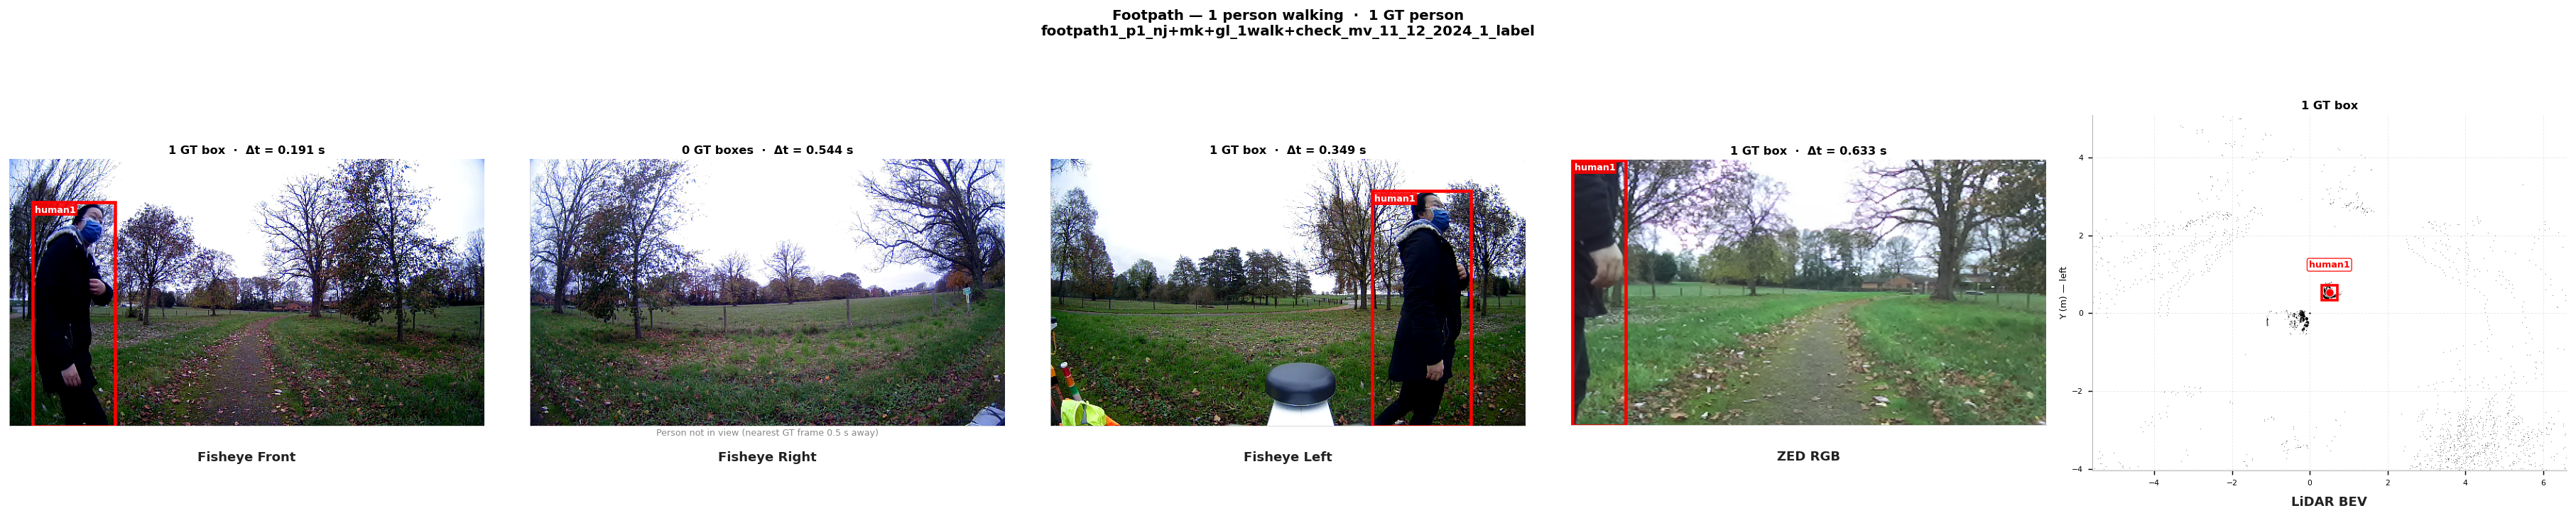

Saved → footpath1_p1_nj_mk_gl_1walk_check_mv_11_12_20_gt_viz.png
  LiDAR : 1731407366_509315147.pcd  (ts=1731407366.5093  labels=1)
  Fisheye Front  : 1731407366_700742211.png  (dt=0.191s  labels=1  [OK])
  Fisheye Right  : 1731407367_053037803.png  (dt=0.544s  labels=0  [NO SYNC])
  Fisheye Left   : 1731407366_857994415.png  (dt=0.349s  labels=1  [OK])
  ZED RGB        : 1731407367_142145459.png  (dt=0.633s  labels=1  [OK])


In [100]:
bag1 = 'footpath1_p1_nj+mk+gl_1walk+check_mv_11_12_2024_1_label'
visualize_bag(bag1, BAGS[bag1])

---
## Bag 2 — Indoor straw, 3 picking workers (occlusion)

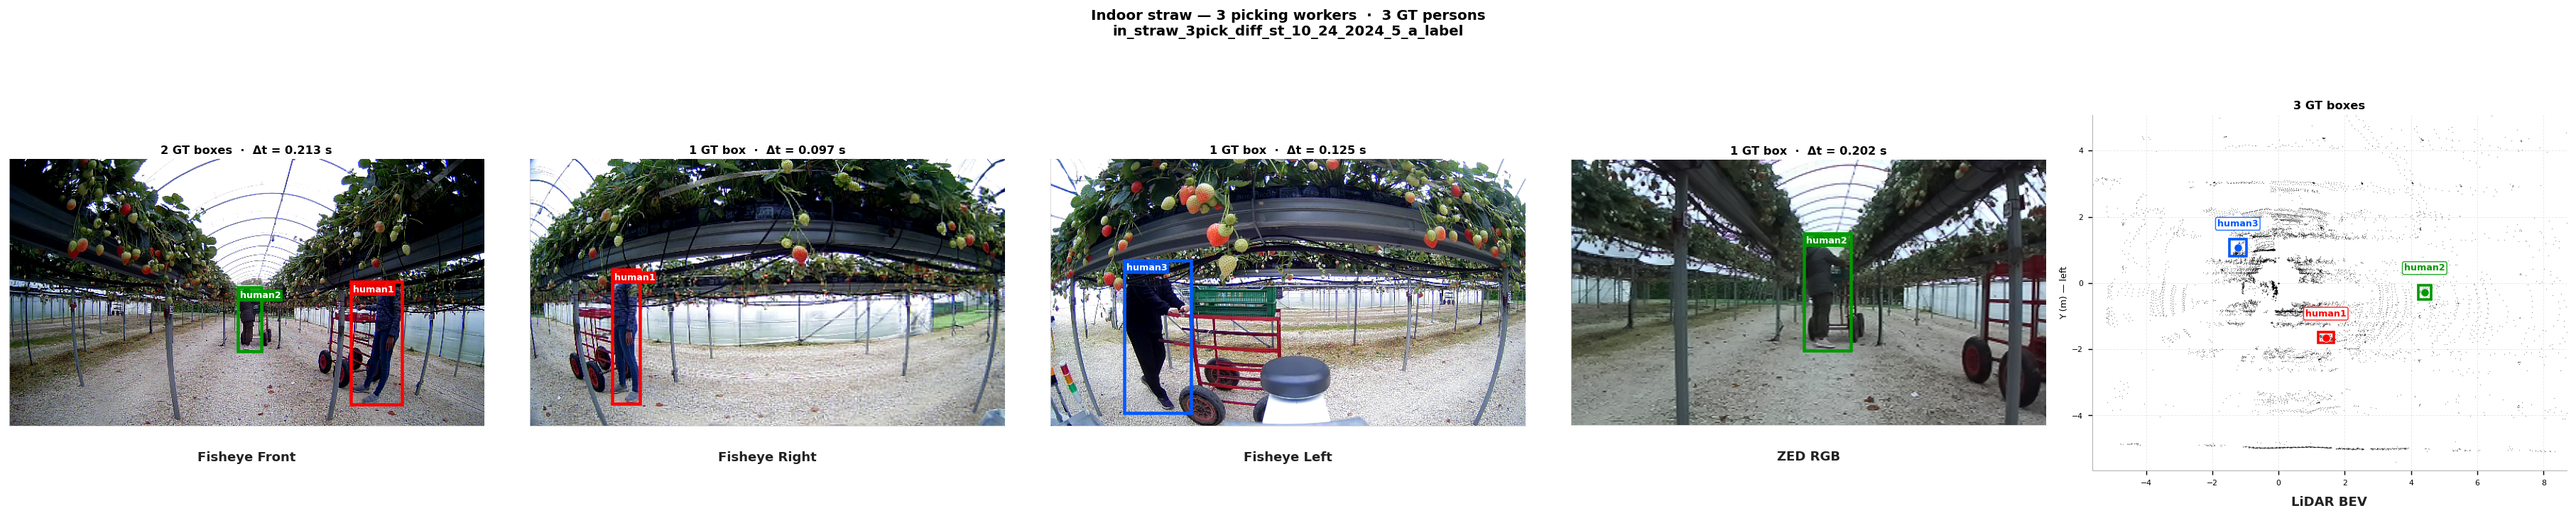

Saved → in_straw_3pick_diff_st_10_24_2024_5_a_label_gt_viz.png
  LiDAR : 1729759535_665940201.pcd  (ts=1729759535.6659  labels=3)
  Fisheye Front  : 1729759535_878831469.png  (dt=0.213s  labels=2  [OK])
  Fisheye Right  : 1729759535_763038002.png  (dt=0.097s  labels=1  [OK])
  Fisheye Left   : 1729759535_790912213.png  (dt=0.125s  labels=1  [OK])
  ZED RGB        : 1729759535_867983531.png  (dt=0.202s  labels=1  [OK])


In [101]:
bag2 = 'in_straw_3pick_diff_st_10_24_2024_5_a_label'
visualize_bag(bag2, BAGS[bag2])

---
## Bag 3 — Outdoor vineyard, 4 swap+walk workers (occlusion)

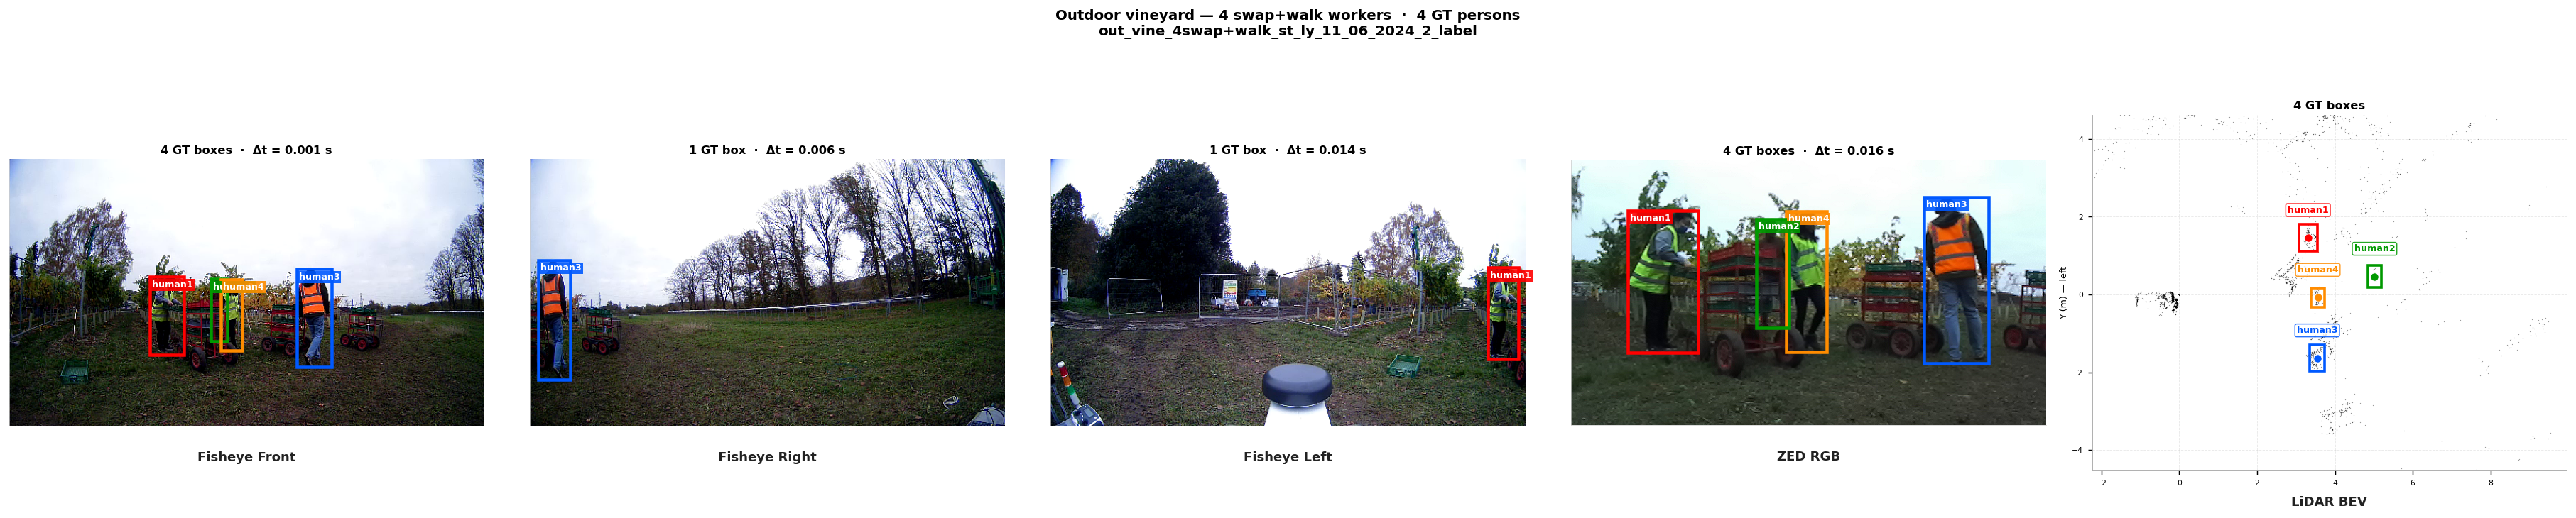

Saved → out_vine_4swap_walk_st_ly_11_06_2024_2_label_gt_viz.png
  LiDAR : 1730892897_696355639.pcd  (ts=1730892897.6964  labels=4)
  Fisheye Front  : 1730892897_697197574.png  (dt=0.001s  labels=4  [OK])
  Fisheye Right  : 1730892897_690609123.png  (dt=0.006s  labels=1  [OK])
  Fisheye Left   : 1730892897_709906396.png  (dt=0.014s  labels=1  [OK])
  ZED RGB        : 1730892897_680161740.png  (dt=0.016s  labels=4  [OK])


In [102]:
bag3 = 'out_vine_4swap+walk_st_ly_11_06_2024_2_label'
visualize_bag(bag3, BAGS[bag3])